# FWI com Unets

In [1]:
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import clear_output


import numpy as np

import tensorflow as tf
from tensorflow.keras import  layers, Model

from geod67lib.unet import create_migration_map
from geod67lib.normalization import create_normalization_transforms
from geod67lib.plotting import plot_image, plot_seismogram
from geod67lib.wavefield import WaveSolverLayer, AquisitionParameters, generate_damp_mask

2026-06-22 13:04:58.800833: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Modelo de velocidade e imagem migrada

In [2]:
# shape = (1024, 512)
shape = (256, 256)
spacing = (10, 10)

width, height = (shape[0] - 1)*spacing[0], (shape[1] - 1)*spacing[1]

In [3]:
vp_true = np.fromfile(f'./data/marmo_vp_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))
vp_0 = np.fromfile(f'./data/vp0_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))
zeta = np.fromfile(f'./data/mig_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))

In [4]:
vpmin = vp_true.min()*.9
vpmax = vp_true.max()*1.1

vpmin, vpmax

(np.float32(1.3499999), np.float32(4.895))

In [5]:
normalize, denormalize = create_normalization_transforms(vpmin, vpmax)

In [6]:
m_0 = normalize(tf.constant(vp_0))

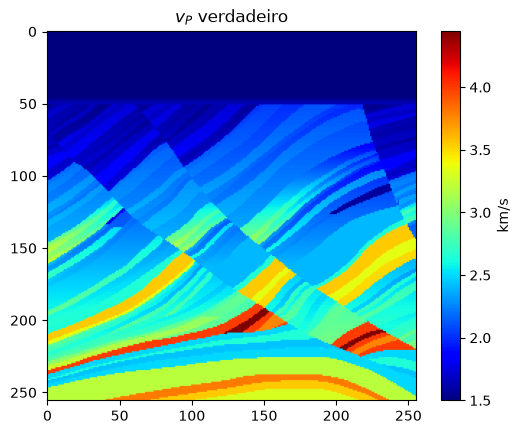

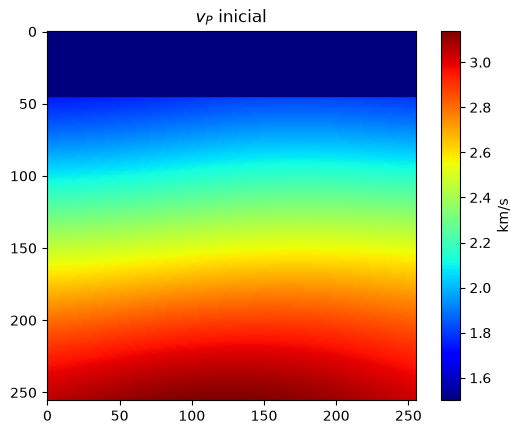

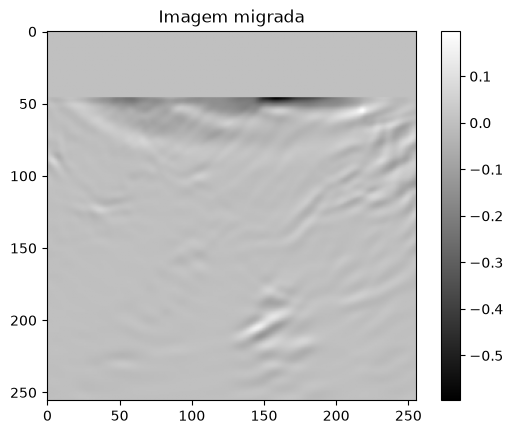

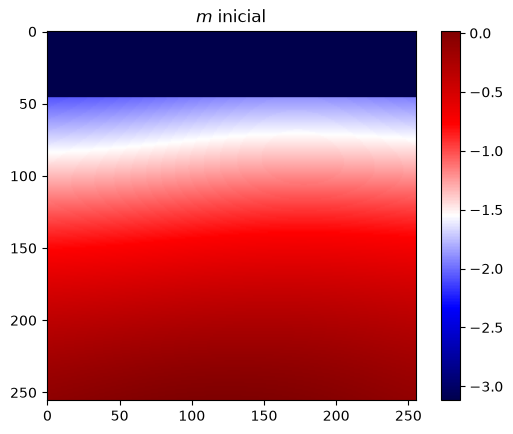

In [7]:
plot_image(vp_true, title='$v_P$ verdadeiro', label='km/s')
plot_image(vp_0, title='$v_P$ inicial', label='km/s')
plot_image(zeta, title='Imagem migrada', cmap='gray')
plot_image(m_0.numpy(), title='$m$ inicial', cmap='seismic')

## Construção da Rede

In [8]:
migmap = create_migration_map(*shape)

In [9]:
zeta_in = tf.constant(zeta)
np.min(zeta_in), np.max(zeta_in)

(np.float32(-0.596494), np.float32(0.19768742))

In [10]:
dm = migmap(zeta_in)
np.min(dm), np.max(dm)

(np.float32(-0.12599507), np.float32(0.038658954))

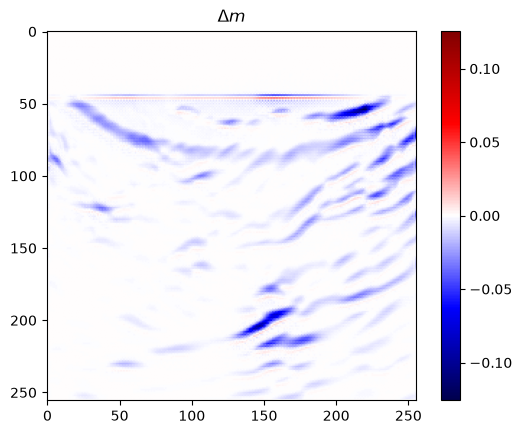

In [11]:
d = dm.numpy()
d = d - np.median(d)
plot_image(d, cmap='seismic', vmin=-np.abs(d).max(), vmax=np.abs(d).max(), title='$\\Delta m$')

## Operador de modelagem

In [12]:
nbl = 40

In [13]:
ap = AquisitionParameters.load('./data/aquisition-params.json')

nrec = ap.nrec
nsrc = ap.nsrc
nt = ap.nt

src_positions = ap.src_positions
ap.src_positions = np.zeros((1, 2))

In [14]:
vp0_pad = np.pad(vp_0[0, :, :, 0], nbl, mode='edge')
vp0_pad = vp0_pad.reshape((1, *vp0_pad.shape, 1))
damp_mask = generate_damp_mask(vp0_pad, nbl)

In [15]:
damp_mask.shape

(1, 336, 336, 1)

## Dado observado

In [16]:
dobs = np.fromfile('./data/dobs_nx256nz256dx10dz10.bin', dtype=np.float32).reshape(nsrc, nrec, nt)

In [17]:
slider = widgets.IntSlider(min=0, max=nsrc-1, description='Shot index')
@widgets.interact(idx=slider)
def plot_seismogram_interact(idx):
    plot_seismogram(dobs[idx], width, ap.tn)

interactive(children=(IntSlider(value=0, description='Shot index', max=4), Output()), _dom_classes=('widget-in…

## Inversão

In [18]:
migmap.input, migmap.output

(<KerasTensor shape=(None, 256, 256, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor>,
 <KerasTensor shape=(None, 256, 256, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_44>)

In [19]:
dm = migmap.output
m = layers.Add()([dm, m_0])
out = WaveSolverLayer(ap, damp_mask, src_positions, spacing=spacing)(m)
out

<KerasTensor shape=(5, 256, 4000), dtype=float32, sparse=False, ragged=False, name=keras_tensor_46>

In [20]:
model = Model(inputs=migmap.input,outputs=out,name='train_net')
model

<Functional name=train_net, built=True>

In [21]:
model.output

<KerasTensor shape=(5, 256, 4000), dtype=float32, sparse=False, ragged=False, name=keras_tensor_46>

In [22]:
with tf.GradientTape() as g:
    dcalc = model(zeta_in)
    res = dcalc - dobs
    phi = tf.reduce_mean(tf.square(res))

    grad = g.gradient(phi, model.variables[0])
grad

<tf.Tensor: shape=(3, 3, 1, 8), dtype=float32, numpy=
array([[[[-3.8358721e-09,  1.1558357e-08, -4.7847282e-10,
          -2.5484466e-09,  1.3038190e-08,  2.0799398e-09,
          -2.2802942e-09,  2.2022530e-09]],

        [[-1.3568979e-08,  1.1010540e-08,  1.4907118e-09,
          -3.9783048e-09,  1.7005846e-08,  3.5015133e-09,
           6.7736741e-09,  4.2358099e-09]],

        [[-2.1118236e-08,  1.3753471e-08,  4.1034918e-09,
          -5.3856830e-09,  2.3444191e-08,  4.8408872e-09,
           1.6078651e-08,  5.9672960e-09]]],


       [[[-5.0711315e-09,  1.1805140e-08, -1.0854395e-10,
          -2.1487381e-09,  1.2632440e-08,  2.5696849e-09,
          -1.5698971e-09,  2.3701319e-09]],

        [[-1.4607238e-08,  1.1039788e-08,  1.8371059e-09,
          -3.5378460e-09,  1.6791027e-08,  3.9111985e-09,
           7.4550615e-09,  4.5298569e-09]],

        [[-2.1773502e-08,  1.3488680e-08,  4.3574078e-09,
          -4.9797402e-09,  2.3214810e-08,  5.1708580e-09,
           1.6568002e-0

In [23]:
model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam()
)

In [24]:
x_train = zeta
y_train = dobs.reshape((1, *dobs.shape))

In [25]:
history = model.fit(
    x_train,
    y_train,
    batch_size=1,
    epochs=5
)

Epoch 1/5


E0000 00:00:1782146301.388675 3311072 message_lite.cc:601] tensorflow.FunctionDef exceeded maximum protobuf size of 2GB: 9428108291
E0000 00:00:1782146301.709803 3311072 message_lite.cc:601] tensorflow.FunctionDef exceeded maximum protobuf size of 2GB: 9428108291
E0000 00:00:1782147162.605482 3311072 message_lite.cc:601] tensorflow.FunctionDef exceeded maximum protobuf size of 2GB: 9427897961
E0000 00:00:1782147162.915989 3311072 message_lite.cc:601] tensorflow.FunctionDef exceeded maximum protobuf size of 2GB: 9427897961
E0000 00:00:1782147163.229118 3311072 message_lite.cc:601] tensorflow.FunctionDef exceeded maximum protobuf size of 2GB: 9427897961


ValueError: Signature specifies 0 arguments, got: 163. Expected inputs: []. Received inputs: (<tf.Tensor 'IteratorGetNext:0' shape=(1, 256, 256, 1) dtype=float32>, <tf.Tensor 'IteratorGetNext:1' shape=(1, 5, 256, 4000) dtype=float32>, <tf.Tensor: shape=(), dtype=resource, value=<ResourceHandle(name="conv2d/kernel/0", device="/job:localhost/replica:0/task:0/device:CPU:0", container="Anonymous", type="tensorflow::Var", dtype and shapes : "[ DType enum: 1, Shape: [3,3,1,8] ]")>>, <tf.Tensor: shape=(), dtype=resource, value=<ResourceHandle(name="conv2d/bias/1", device="/job:localhost/replica:0/task:0/device:CPU:0", container="Anonymous", type="tensorflow::Var", dtype and shapes : "[ DType enum: 1, Shape: [8] ]")>>, <tf.Tensor: shape=(), dtype=resource, value=<ResourceHandle(name="batch_normalization/moving_mean/4", device="/job:localhost/replica:0/task:0/device:CPU:0", container="Anonymous", type="tensorflow::Var", dtype and shapes : "[ DType enum: 1, Shape: [8] ]")>>, <tf.Tensor: shape=()